<!-- KERNEL_BANNER -->
> **Use kernel: `mrigi_tor190_v8`**
>
> Set the notebook kernel to *Python (mrigi_tor190_v8)* before running.

# 30c: Where do the FT models beat / lose to the base Llama?

Consumes the **dual-judge** JSON produced by 30b (`judge_results_23j_dual_final_*.json`).

For every FT model separately (per user request):

1. Compute per-question `correctness_score(FT) − correctness_score(Llama-3-8B-Instruct)` for each judge and method.
2. Rank questions: **top-K wins** (FT beats base) and **top-K losses** (FT worse than base).
3. Cluster the 100 questions into ~6–8 zeolite-science topics using GPT-4.1, then show per-topic win/loss patterns per FT model.

The result is one win/loss table per FT model plus a per-model topic breakdown.

In [1]:
import os
import json
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
from openai import OpenAI
import httpx

with open('/home/jupyter/Mrigi/env.sh') as f:
    for line in f:
        line = line.strip()
        if line.startswith('export ') and '=' in line:
            key, val = line[len('export '):].split('=', 1)
            os.environ[key] = val.strip('"').strip("'")

client = OpenAI(api_key=os.environ['OPENAI_API_TOKEN'], http_client=httpx.Client())
print('✓ OpenAI client ready')
print(f'✓ timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✓ OpenAI client ready
✓ timestamp: 2026-07-21 17:26:47


## Load the dual-judge JSON produced by 30b

In [2]:
# Pick the most recent dual-judge file, unless JUDGE_FILE is overridden.
JUDGE_FILE = None
if JUDGE_FILE is None:
    candidates = sorted(glob.glob('judge_results_23j_dual_final_*.json'))
    if not candidates:
        raise FileNotFoundError('No dual-judge results file — run the dual-judge 30b first.')
    JUDGE_FILE = candidates[-1]

with open(JUDGE_FILE) as f:
    payload = json.load(f)

assert payload.get('metadata', {}).get('schema') == 'dual-judge-v1', \
    f"Expected dual-judge-v1 schema in {JUDGE_FILE}. Re-run 30b (dual-judge) first."

META = payload['metadata']
RES  = payload['results']
JUDGE_MODELS = META['judge_models']
METHODS      = META['methods']
MODELS       = META['models_judged']

BASE_MODEL = 'Llama-3-8B-Instruct'
assert BASE_MODEL in MODELS, f'Base model {BASE_MODEL!r} not in judged models — cannot compute FT-vs-base deltas.'
FT_MODELS = [m for m in MODELS if m != BASE_MODEL]

print(f'Loaded: {JUDGE_FILE}')
print(f'  judge models: {JUDGE_MODELS}')
print(f'  methods:      {METHODS}')
print(f'  base model:   {BASE_MODEL}')
print(f'  FT models ({len(FT_MODELS)}):')
for m in FT_MODELS:
    print(f'    • {m}')

Loaded: judge_results_23j_dual_final_20260721_165400.json
  judge models: ['gpt-4.1', 'gpt-4o']
  methods:      ['no_context', 'mmr']
  base model:   Llama-3-8B-Instruct
  FT models (6):
    • DAPT_LR1e5
    • synv2V2_step80
    • synv2V2_final
    • synv2_base_step80
    • synv2_base_final
    • fullpaper_120M_LR1e5


## Flatten to a long DataFrame keyed by (question, model, method, judge)

In [3]:
TASKS = ['relevance', 'correctness', 'completeness', 'faithfulness']

rows = []
for model in MODELS:
    for method in METHODS:
        for q_idx, r in enumerate(RES[model][method]):
            for jm in JUDGE_MODELS:
                j = r['judges'][jm]
                rows.append({
                    'q_idx': q_idx,
                    'model': model,
                    'method': method,
                    'judge': jm,
                    'query': r.get('query'),
                    'title': r.get('title'),
                    'doi': r.get('doi'),
                    'gold_answer': r.get('gold_answer'),
                    'model_answer': r.get('model_answer'),
                    'relevance': j['relevance_score'],
                    'correctness': j['correctness_score'],
                    'completeness': j['completeness_score'],
                    'faithfulness': j['faithfulness_score'],
                })

long_df = pd.DataFrame(rows)
print(f'✓ long_df shape: {long_df.shape}')
print(f'  expected rows: {len(MODELS)} × {len(METHODS)} × 100 × {len(JUDGE_MODELS)} = '
      f'{len(MODELS) * len(METHODS) * 100 * len(JUDGE_MODELS)}')
long_df.head()

✓ long_df shape: (2800, 13)
  expected rows: 7 × 2 × 100 × 2 = 2800


,q_idx,model,method,judge,query,title,doi,gold_answer,model_answer,relevance,correctness,completeness,faithfulness
0,0,Llama-3-8B-Instruct,no_context,gpt-4.1,In zeolite synthesis from a sodium–organic–sil...,Zeolite synthesis in presence of hexamethonium...,10.1016/j.molcata.2008.12.024,It acts as a structure-directing agent whose f...,<|begin_of_text|><|start_header_id|>user<|end_...,-1,8,8,7
1,0,Llama-3-8B-Instruct,no_context,gpt-4o,In zeolite synthesis from a sodium–organic–sil...,Zeolite synthesis in presence of hexamethonium...,10.1016/j.molcata.2008.12.024,It acts as a structure-directing agent whose f...,<|begin_of_text|><|start_header_id|>user<|end_...,-1,8,9,9
2,1,Llama-3-8B-Instruct,no_context,gpt-4.1,In the synthesis of hierarchical mesoporous ze...,Hierarchical mesoporous zeolites with controll...,10.1016/j.micromeso.2009.12.001,It acts as a mesoscale porogen that organizes ...,<|begin_of_text|><|start_header_id|>user<|end_...,-1,9,8,9
3,1,Llama-3-8B-Instruct,no_context,gpt-4o,In the synthesis of hierarchical mesoporous ze...,Hierarchical mesoporous zeolites with controll...,10.1016/j.micromeso.2009.12.001,It acts as a mesoscale porogen that organizes ...,<|begin_of_text|><|start_header_id|>user<|end_...,-1,9,9,9
4,2,Llama-3-8B-Instruct,no_context,gpt-4.1,In hydrothermal synthesis of zeolite-type fram...,Two Ethylenediamine-Templated Zeolite-Type Str...,10.1006/jssc.1997.7680,It acts as a structure-directing agent that st...,<|begin_of_text|><|start_header_id|>user<|end_...,-1,8,8,9


## Per-FT-model win/loss lists vs Llama base

For each FT model and each (method, judge) combo, compute the per-question correctness delta vs `Llama-3-8B-Instruct`. Skip questions where either side has an invalid score (`< 1`). Report the top-N wins and top-N losses.

In [4]:
TOP_N = 10  # per (FT model, method, judge)

# Pivot to a wide table indexed by q_idx with per-model correctness columns
def wide_correctness(method, judge):
    sub = long_df[(long_df['method'] == method) & (long_df['judge'] == judge)].copy()
    sub = sub[sub['correctness'] >= 1]  # drop ERROR/INVALID/skipped
    wide = sub.pivot_table(index=['q_idx', 'query', 'title', 'gold_answer'],
                            columns='model', values='correctness', aggfunc='first').reset_index()
    return wide

win_loss_records = []  # for CSV export

for ft in FT_MODELS:
    for method in METHODS:
        for jm in JUDGE_MODELS:
            w = wide_correctness(method, jm)
            if BASE_MODEL not in w.columns or ft not in w.columns:
                continue
            w = w[w[BASE_MODEL].notna() & w[ft].notna()].copy()
            w['delta'] = w[ft] - w[BASE_MODEL]

            wins   = w.sort_values('delta', ascending=False).head(TOP_N)
            losses = w.sort_values('delta', ascending=True).head(TOP_N)

            for _, row in wins.iterrows():
                win_loss_records.append({
                    'ft_model': ft, 'method': method, 'judge': jm,
                    'kind': 'win', 'q_idx': int(row['q_idx']),
                    'delta': float(row['delta']),
                    'ft_score': float(row[ft]), 'base_score': float(row[BASE_MODEL]),
                    'title': row['title'],
                    'query': (row['query'] or '')[:220],
                    'gold_answer': (row['gold_answer'] or '')[:220],
                })
            for _, row in losses.iterrows():
                win_loss_records.append({
                    'ft_model': ft, 'method': method, 'judge': jm,
                    'kind': 'loss', 'q_idx': int(row['q_idx']),
                    'delta': float(row['delta']),
                    'ft_score': float(row[ft]), 'base_score': float(row[BASE_MODEL]),
                    'title': row['title'],
                    'query': (row['query'] or '')[:220],
                    'gold_answer': (row['gold_answer'] or '')[:220],
                })

win_loss_df = pd.DataFrame(win_loss_records)
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_path = f'ft_vs_base_win_loss_{ts}.csv'
win_loss_df.to_csv(csv_path, index=False)
print(f'✓ Per-FT-model win/loss CSV: {csv_path}  ({len(win_loss_df)} rows)')

✓ Per-FT-model win/loss CSV: ft_vs_base_win_loss_20260721_172647.csv  (480 rows)


In [5]:
# Pretty-print per-FT-model wins and losses (one section per FT), showing a compact table.
def _fmt_line(row):
    return (f"    q{row['q_idx']:>3}  Δ{row['delta']:+.1f}  "
            f"(ft={row['ft_score']:.0f}, base={row['base_score']:.0f})  "
            f"{(row['title'] or '')[:60]}  |  {(row['query'] or '')[:80]}")

for ft in FT_MODELS:
    print('\n' + '=' * 100)
    print(f'FT model:  {ft}')
    print('=' * 100)
    for method in METHODS:
        for jm in JUDGE_MODELS:
            sub = win_loss_df[(win_loss_df['ft_model'] == ft)
                              & (win_loss_df['method'] == method)
                              & (win_loss_df['judge'] == jm)]
            if sub.empty:
                continue
            wins  = sub[sub['kind'] == 'win'].sort_values('delta', ascending=False)
            loses = sub[sub['kind'] == 'loss'].sort_values('delta', ascending=True)
            print(f'\n  ── method={method:<10s}  judge={jm}  ──')
            print(f'  ✓ TOP {len(wins)} WINS vs {BASE_MODEL}:')
            for _, r in wins.iterrows():
                print(_fmt_line(r))
            print(f'  ✗ TOP {len(loses)} LOSSES vs {BASE_MODEL}:')
            for _, r in loses.iterrows():
                print(_fmt_line(r))


FT model:  DAPT_LR1e5

  ── method=no_context  judge=gpt-4.1  ──
  ✓ TOP 10 WINS vs Llama-3-8B-Instruct:
    q 29  Δ+5.0  (ft=10, base=5)  Synthesis, Characterization, and Adsorption Properties of Na  |  In nanocrystalline ZSM-5, why can a smaller crystal size lead to higher adsorpti
    q 80  Δ+5.0  (ft=10, base=5)  Stabilization effect of phosphorus on steamed H-MFI zeolites  |  In steamed H-MFI zeolites, what broader mechanism best explains how phosphorus a
    q 26  Δ+3.0  (ft=8, base=5)  Creation of mesostructured hollow Y zeolite by selective dem  |  In the sequential SiCl4–HCl–NaOH treatment used to create a hollow mesostructure
    q 65  Δ+3.0  (ft=8, base=5)  Post-Synthesis Functionalization Enables Fine-Tuning the Mol  |  In post-synthesis organic functionalization of zeolites to improve olefin/paraff
    q 73  Δ+3.0  (ft=10, base=7)  A historical note on the sodalite framework: The contributio  |  In zeolite science, what is the most accurate implication of identifying a mi

## Autocluster the 100 questions into ~6–8 zeolite-science topics via GPT-4.1

In [6]:
# Get the unique 100 questions (same across all model×method×judge combos)
q_frame = (long_df[['q_idx', 'query', 'title', 'gold_answer']]
           .drop_duplicates(subset='q_idx').sort_values('q_idx').reset_index(drop=True))
print(f'Unique questions: {len(q_frame)}')

# Prompt GPT-4.1 with the full list, ask it to invent 6–8 topic labels then assign each question.
TOPIC_PROMPT_SYS = (
    "You are an expert in zeolite science. You are given a list of open-ended questions about "
    "zeolite synthesis, characterization, and catalysis. Your job is to produce a small, "
    "MECE topic taxonomy (6–8 labels) covering the whole set, and then classify every question "
    "into exactly one topic. Reply with valid JSON only."
)

# Compact per-question payload
compact_qs = [{'q_idx': int(r.q_idx), 'q': (r.query or '')[:400]} for r in q_frame.itertuples()]

TOPIC_PROMPT_USER = (
    'Here are ' + str(len(compact_qs)) + ' zeolite-science questions:\n\n'
    + json.dumps(compact_qs, ensure_ascii=False)
    + '\n\nReturn ONLY a JSON object of the form:\n'
    + '{\n'
    + '  "topics": ["<label1>", "<label2>", ...],   // 6-8 short kebab-case-ish labels\n'
    + '  "assignments": [{"q_idx": <int>, "topic": "<label>"}, ...]   // exactly one row per q_idx\n'
    + '}\n\n'
    + 'Labels should be substantive (e.g. "OSDA/templating", "hierarchical/mesoporosity", '
    + '"catalysis-hydroisomerization", "membranes/films", "characterization/nmr", "heteroatom-substitution", '
    + '"post-synthesis-modification", "synthesis-mechanism-nucleation"). Use whatever set actually fits the data.'
)

resp = client.chat.completions.create(
    model='gpt-4.1',
    messages=[{'role': 'system', 'content': TOPIC_PROMPT_SYS},
              {'role': 'user',   'content': TOPIC_PROMPT_USER}],
    temperature=0.0, max_tokens=4000,
    response_format={'type': 'json_object'},
)
topic_payload = json.loads(resp.choices[0].message.content)

topics = topic_payload['topics']
assignments = pd.DataFrame(topic_payload['assignments'])

print(f'Topics ({len(topics)}):')
for t in topics:
    print(f'  • {t}')

# Validate: exactly 100 assignments, all q_idx accounted for
assert len(assignments) == len(q_frame), f'Got {len(assignments)} assignments, expected {len(q_frame)}'
assert set(assignments['q_idx']) == set(q_frame['q_idx']), 'Assignments do not cover every q_idx exactly once'

# Merge topic onto long_df
long_df = long_df.merge(assignments, on='q_idx', how='left')

topic_csv = f'topic_assignments_{ts}.csv'
assignments.merge(q_frame, on='q_idx').to_csv(topic_csv, index=False)
print(f'\n✓ Topic assignments CSV: {topic_csv}')
print(f'\nTopic distribution:')
print(assignments['topic'].value_counts().to_string())

Unique questions: 100
Topics (8):
  • osda-structure-directing-agents
  • hierarchical-mesoporosity
  • framework-composition-heteroatoms
  • synthesis-mechanism-nucleation-growth
  • post-synthesis-modification
  • catalysis-performance
  • membranes-films-coatings
  • characterization-structure-properties

✓ Topic assignments CSV: topic_assignments_20260721_172647.csv

Topic distribution:
topic
framework-composition-heteroatoms        25
synthesis-mechanism-nucleation-growth    19
osda-structure-directing-agents          18
hierarchical-mesoporosity                12
membranes-films-coatings                  9
post-synthesis-modification               6
catalysis-performance                     6
characterization-structure-properties     5


## Per-FT-model × per-topic FT-vs-base correctness delta

In [7]:
# For each (ft_model, method, judge, topic), average the per-question correctness delta.
topic_rows = []
for ft in FT_MODELS:
    for method in METHODS:
        for jm in JUDGE_MODELS:
            w = wide_correctness(method, jm)
            if BASE_MODEL not in w.columns or ft not in w.columns:
                continue
            w = w[w[BASE_MODEL].notna() & w[ft].notna()].copy()
            w = w.merge(assignments, on='q_idx', how='left')
            w['delta'] = w[ft] - w[BASE_MODEL]
            for topic, grp in w.groupby('topic'):
                topic_rows.append({
                    'ft_model': ft, 'method': method, 'judge': jm, 'topic': topic,
                    'n': len(grp),
                    'mean_delta': float(grp['delta'].mean()),
                    'ft_mean': float(grp[ft].mean()),
                    'base_mean': float(grp[BASE_MODEL].mean()),
                    'pct_wins': float((grp['delta'] > 0).mean() * 100),
                    'pct_losses': float((grp['delta'] < 0).mean() * 100),
                })

topic_df = pd.DataFrame(topic_rows)
topic_csv2 = f'ft_vs_base_by_topic_{ts}.csv'
topic_df.to_csv(topic_csv2, index=False)
print(f'✓ Per-topic delta CSV: {topic_csv2}')
topic_df.head(20)

✓ Per-topic delta CSV: ft_vs_base_by_topic_20260721_172647.csv


,ft_model,method,judge,topic,n,mean_delta,ft_mean,base_mean,pct_wins,pct_losses
0,DAPT_LR1e5,no_context,gpt-4.1,catalysis-performance,6,0.500000,8.166667,7.666667,33.333333,50.000000
1,DAPT_LR1e5,no_context,gpt-4.1,characterization-structure-properties,5,1.400000,8.400000,7.000000,40.000000,20.000000
2,DAPT_LR1e5,no_context,gpt-4.1,framework-composition-heteroatoms,25,-0.160000,7.040000,7.200000,40.000000,40.000000
3,DAPT_LR1e5,no_context,gpt-4.1,hierarchical-mesoporosity,12,-0.333333,7.416667,7.750000,33.333333,33.333333
4,DAPT_LR1e5,no_context,gpt-4.1,membranes-films-coatings,9,-0.444444,6.666667,7.111111,11.111111,33.333333
5,DAPT_LR1e5,no_context,gpt-4.1,osda-structure-directing-agents,18,-0.444444,6.888889,7.333333,16.666667,50.000000
6,DAPT_LR1e5,no_context,gpt-4.1,post-synthesis-modification,6,0.166667,7.000000,6.833333,33.333333,16.666667
7,DAPT_LR1e5,no_context,gpt-4.1,synthesis-mechanism-nucleation-growth,19,-0.263158,6.684211,6.947368,26.315789,36.842105
8,DAPT_LR1e5,no_context,gpt-4o,catalysis-performance,6,0.833333,8.000000,7.166667,33.333333,33.333333
9,DAPT_LR1e5,no_context,gpt-4o,characterization-structure-properties,5,0.800000,7.800000,7.000000,40.000000,20.000000


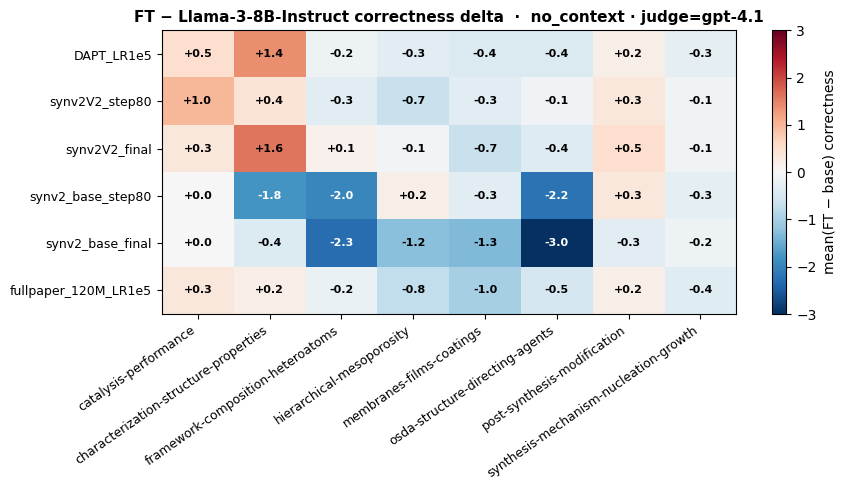

✓ Saved: ft_vs_base_topic_heatmap_no_context_gpt-4.1_20260721_172647.svg


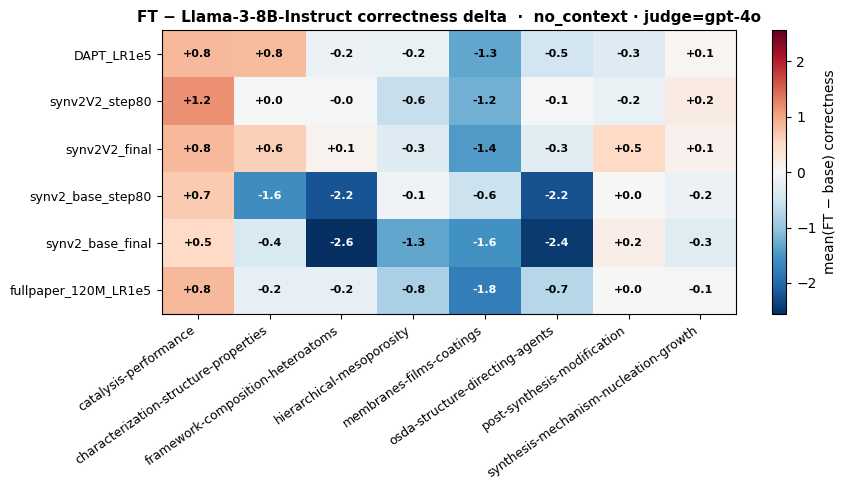

✓ Saved: ft_vs_base_topic_heatmap_no_context_gpt-4o_20260721_172647.svg


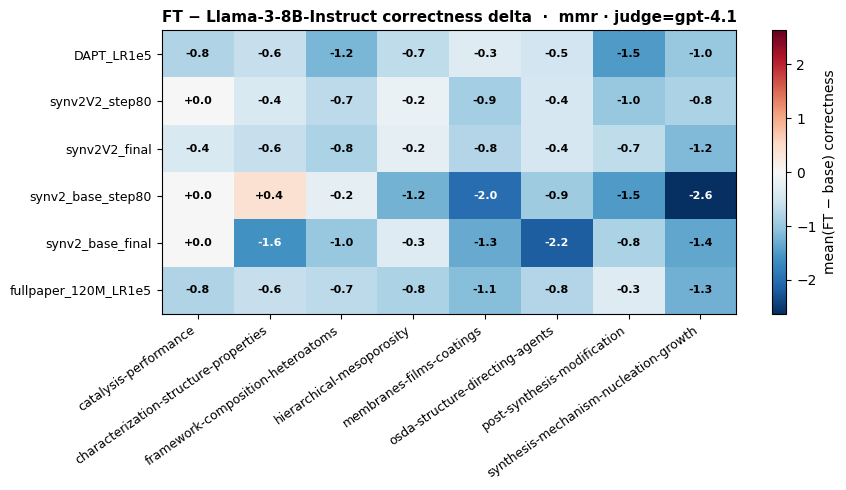

✓ Saved: ft_vs_base_topic_heatmap_mmr_gpt-4.1_20260721_172647.svg


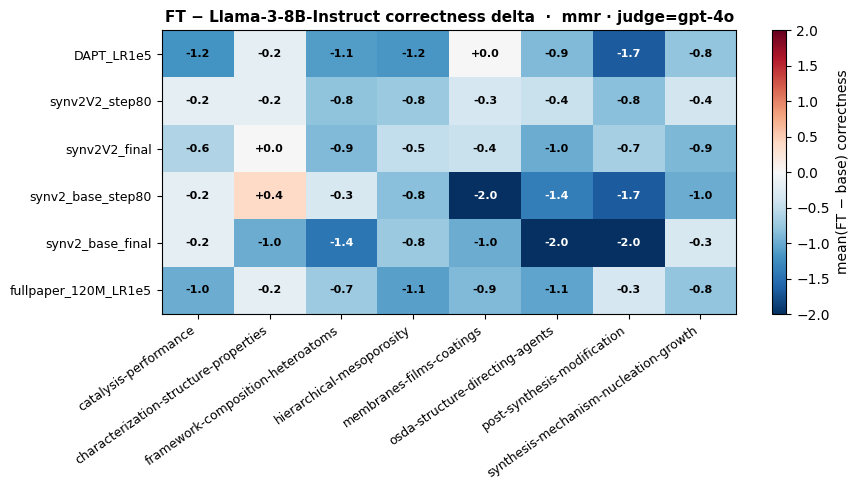

✓ Saved: ft_vs_base_topic_heatmap_mmr_gpt-4o_20260721_172647.svg


In [8]:
# Heatmap per (method, judge): rows = FT models, cols = topics, cell = mean correctness delta vs base.
for method in METHODS:
    for jm in JUDGE_MODELS:
        sub = topic_df[(topic_df['method'] == method) & (topic_df['judge'] == jm)]
        if sub.empty:
            continue
        pivot = sub.pivot(index='ft_model', columns='topic', values='mean_delta').reindex(FT_MODELS)
        pivot = pivot.reindex(sorted(pivot.columns), axis=1)
        data = pivot.values.astype(float)
        vmax = float(np.nanmax(np.abs(data))) if not np.all(np.isnan(data)) else 1.0
        vmax = max(vmax, 0.5)

        fig, ax = plt.subplots(figsize=(max(9, len(pivot.columns) * 1.1), max(5, len(FT_MODELS) * 0.5)))
        im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=35, ha='right', fontsize=9)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=9)
        ax.set_title(f'FT − {BASE_MODEL} correctness delta  ·  {method} · judge={jm}',
                     fontsize=11, fontweight='bold')
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                v = data[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:+.1f}', ha='center', va='center',
                            fontsize=8,
                            color='white' if abs(v) > vmax * 0.6 else 'black',
                            fontweight='bold')
        fig.colorbar(im, ax=ax, label='mean(FT − base) correctness')
        plt.tight_layout()
        out = f'ft_vs_base_topic_heatmap_{method}_{jm}_{ts}.svg'
        fig.savefig(out, format='svg', bbox_inches='tight')
        plt.show()
        print(f'✓ Saved: {out}')

## Per-FT-model overall summary (both judges + both methods, aggregated)

In [9]:
# For each FT model, aggregate to a single row per (method, judge) with mean delta + win/loss counts.
agg_rows = []
for ft in FT_MODELS:
    for method in METHODS:
        for jm in JUDGE_MODELS:
            w = wide_correctness(method, jm)
            if BASE_MODEL not in w.columns or ft not in w.columns:
                continue
            w = w[w[BASE_MODEL].notna() & w[ft].notna()].copy()
            w['delta'] = w[ft] - w[BASE_MODEL]
            agg_rows.append({
                'ft_model': ft, 'method': method, 'judge': jm,
                'n': len(w),
                'mean_delta': float(w['delta'].mean()),
                'ft_mean_correctness':  float(w[ft].mean()),
                'base_mean_correctness': float(w[BASE_MODEL].mean()),
                'n_wins': int((w['delta'] > 0).sum()),
                'n_ties': int((w['delta'] == 0).sum()),
                'n_losses': int((w['delta'] < 0).sum()),
            })

agg_df = pd.DataFrame(agg_rows)
agg_csv = f'ft_vs_base_overall_{ts}.csv'
agg_df.to_csv(agg_csv, index=False)
print(f'✓ Overall FT-vs-base CSV: {agg_csv}')
agg_df.pivot_table(index='ft_model', columns=['method', 'judge'], values='mean_delta').round(2)

✓ Overall FT-vs-base CSV: ft_vs_base_overall_20260721_172647.csv


method                   mmr        no_context       
judge                gpt-4.1 gpt-4o    gpt-4.1 gpt-4o
ft_model                                             
DAPT_LR1e5             -0.86  -0.91      -0.14  -0.19
fullpaper_120M_LR1e5   -0.85  -0.82      -0.35  -0.41
synv2V2_final          -0.71  -0.75       0.00  -0.07
synv2V2_step80         -0.60  -0.55      -0.13  -0.10
synv2_base_final       -1.20  -1.15      -1.45  -1.42
synv2_base_step80      -1.14  -0.90      -1.02  -1.08

In [10]:
print('=' * 80)
print('30c — FT vs Base analysis complete')
print('=' * 80)
print(f'Source judge JSON:            {JUDGE_FILE}')
print(f'Per-FT win/loss CSV:          ft_vs_base_win_loss_{ts}.csv')
print(f'Topic assignments CSV:        topic_assignments_{ts}.csv')
print(f'Per-topic delta CSV:          ft_vs_base_by_topic_{ts}.csv')
print(f'Overall per-FT-model CSV:     ft_vs_base_overall_{ts}.csv')
print(f'Per-topic heatmaps (SVG):     ft_vs_base_topic_heatmap_*_{ts}.svg')
print('=' * 80)

30c — FT vs Base analysis complete
Source judge JSON:            judge_results_23j_dual_final_20260721_165400.json
Per-FT win/loss CSV:          ft_vs_base_win_loss_20260721_172647.csv
Topic assignments CSV:        topic_assignments_20260721_172647.csv
Per-topic delta CSV:          ft_vs_base_by_topic_20260721_172647.csv
Overall per-FT-model CSV:     ft_vs_base_overall_20260721_172647.csv
Per-topic heatmaps (SVG):     ft_vs_base_topic_heatmap_*_20260721_172647.svg
